In [376]:
import asyncio
from sipyco.sync_struct import Subscriber

# Create an asyncio Event to wait for updates
dataset_updated = asyncio.Event()


async def connect_subscriber(name, db: dict, port=None, server=None):
    port = 3250 if port is None else port
    server = "137.222.69.28" if server is None else server

    def _create(data):
        db.update(data)
        return db

    def _update(mod):
        # Signal that an update has occurred
        dataset_updated.set()

    subscriber = Subscriber(name, _create, _update, None)
    try:
        await subscriber.connect(
            server,
            port,
        )
    except asyncio.TimeoutError:
        print(f"Failed to connect to Sub: {name} at {server}:{port}")
        return
    print(f"Connected to Sub: {name} at {server}:{port}")
    return subscriber

**DO NOT add extra code to this lower cell.**

Due to jupyter notebook async weirdness it won't actually await the return before running subsequent code

In [377]:
# Run the connection in an asyncio event loop
db = {}
sub = await connect_subscriber("datasets", db)
await dataset_updated.wait()
# await sub.close()
print("Received dataset update!")

Connected to Sub: datasets at 137.222.69.28:3250
Received dataset update!


In [378]:
import numpy as np

# get the RID of the latest dataset
keys = list(db.keys())
# find ones with ndscan.rid_NUM.source_id
rid_keys = [
    key.split(".")[1][4:]
    for key in keys
    if key.startswith("ndscan.rid_") and key.endswith(".source_id")
]
if rid_keys:
    RID = rid_keys[-1]  # Get the last RID in the list
else:
    raise ValueError("No ndscan datasets found.")
print(f"Selected RID: {RID} from {rid_keys}")

print(f"Dataset keys: {list(db.keys())}")


Selected RID: 26851 from ['26851']
Dataset keys: ['fastino.leds', 'fastino.voltages', 'mirny.atts', 'mirny.en_almazny', 'mirny.en_outs', 'mirny.freqs', 'suservo.Gls', 'suservo.Is', 'suservo.Ps', 'suservo.atts', 'suservo.calib_gains', 'suservo.calib_offsets', 'suservo.en_iirs', 'suservo.en_outs', 'suservo.en_shutters', 'suservo.enabled', 'suservo.freqs', 'suservo.gains', 'suservo.offsets', 'suservo.ys', 'Images.absorption.TOF', 'Images.absorption.REF', 'Images.absorption.BG', 'Images.absorption.expansion_time', 'Images.absorption.settings', 'Images.absorption.timestamp', 'ndscan.rid_26851.ndscan_schema_revision', 'ndscan.rid_26851.source_id', 'ndscan.rid_26851.completed', 'ndscan.rid_26851.execution_mode', 'ndscan.rid_26851.fragment_fqn', 'ndscan.rid_26851.axes', 'ndscan.rid_26851.seed', 'ndscan.rid_26851.channels', 'ndscan.rid_26851.annotations', 'ndscan.rid_26851.online_analyses', 'ndscan.rid_26851.analysis_results', 'ndscan.rid_26851.points.channel_atom_number', 'ndscan.rid_26851.poi

Num points: 26
Failed shots: 53.85%
Mean atom number: -infe8 +- nane8
Atom number at best parameters: -infe8
Best objective value: nan
PGC_Ramp: Supplies end - Y: 0.09655172413793103


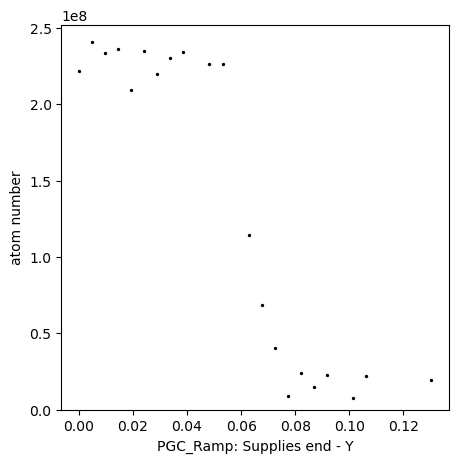

In [380]:
import matplotlib.pyplot as plt
import json
import numpy as np

axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

fig,ax = plt.subplots(1, num_axes, figsize=(5*num_axes, 5))
if num_axes == 1:
    ax = [ax]  # Ensure ax is always a list for consistency
for i in range(num_axes):
    ax[i].scatter(
        db[f"ndscan.rid_{RID}.points.axis_{i}"][1],
        db[f"ndscan.rid_{RID}.points.channel_atom_number"][1],
        s=2,
        color='k',
    )

    ax[i].set_xlabel(axes[i]["param"]["description"])
    ax[i].set_ylabel("atom number")
    ax[i].set_ylim(bottom=0)

numbers= db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]
print(f"Num points: {len(numbers)}")

# count the nummber of failed shots(atom < 30% mean )
# failed_shots = np.sum(numbers < 0.7 * np.mean(numbers))
failed_shots = 0
for i in range(len(numbers)):
    if numbers[i] < 1e8:
        failed_shots += 1
print(f"Failed shots: {failed_shots / len(numbers) * 100:.2f}%")

for i in range(1,num_axes):
    ax[i].axhline(np.mean(numbers), color='b', linestyle='--', )
# ax[0].axhline(np.mean(numbers), color='b', linestyle='--', label='Mean = {:.2f}e8'.format(np.mean(numbers) / 1e8))
# ax[0].legend(loc="lower right")

# atom number and uncertainty
print(f"Mean atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8")

# obtain current best optimization parameterss
objective = np.array(db.get(f"ndscan.rid_{RID}.points.channel_custom_objective")[1])
axes_array = np.array(db.get(f"ndscan.rid_{RID}.axes")[1])

# find best results 
best_index = np.argmin(objective)
best_objective = objective[best_index]
best_axes = {}
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best parameters: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best objective value: {best_objective}")
for name, value in best_axes.items():
    print(f"{name}: {value}")



In [347]:
# best index based on PSD
PSD = np.array(db.get(f"ndscan.rid_{RID}.points.channel_phase_space_density")[1])
best_index = np.argmax(PSD)
best_PSD = PSD[best_index]
best_axes = {}
best_sigma_x = db.get(f"ndscan.rid_{RID}.points.channel_sigmax_mm")[1][best_index]
best_sigma_y = db.get(f"ndscan.rid_{RID}.points.channel_sigmay_mm")[1][best_index]
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best PSD: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best PSD: {best_PSD:.2e}")
print(f"Best sigma_x: {best_sigma_x:.2f} mm")
print(f"Best sigma_y: {best_sigma_y:.2f} mm")
for name, value in best_axes.items():
    print(f"{name}: {value}")

# # make a scatter plot of atom number vs total time = axis_0 + axis_1
# fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
# t1 = db[f"ndscan.rid_{RID}.points.axis_1"][1]
# t2 = db[f"ndscan.rid_{RID}.points.axis_2"][1]
# N = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
# t_total = np.array(t1) + np.array(t2)
# t_frac = np.array(t1) / t_total

# ax[0].scatter(
#     t_total *1e3,
#     N,
#     s=2,color='k',)
# ax[0].set_xlabel("Total Time (ms)")
# ax[0].set_ylabel("Atom Number")
# ax[1].scatter(
#     t_frac,
#     N,
#     s=2,color='k',)
# ax[1].set_xlabel(f"Time Fraction : $t_{{ramp}}/t_{{total}}$")
# ax[1].set_ylabel("Atom Number")
# ax[0].set_title("Scatter Plot of Atom Number vs Total Time")
# ax[1].set_title("Scatter Plot of Atom Number vs Time Fraction")
# plt.show()



Atom number at best PSD: 2.49e8
Best PSD: 1.07e-07
Best sigma_x: 1.58 mm
Best sigma_y: 1.54 mm
Detuning of the PGC ramp: 60286100.0
Attenuation of the PGC Repump beam: 0.05
Duration of the PGC ramp: 0.014580000000000001


In [6]:
import numpy as np
import matplotlib.pyplot as plt

loading = np.asarray(db[f"ndscan.rid_{RID}.points.channel_mot_voltages"][1])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i in range(len(numbers)):
    color = 'r' if numbers[i] < 1e8 else 'b'
    ax[1].plot(np.arange(0,30,3), loading[i], color=color, alpha=0.5, linewidth=0.5)

ax[1].legend(title="Number of atoms", labels=["< 1e8", "> 1e8"])
ax[1].set_xlabel("Loading time (s)")
ax[1].set_ylabel("MOT photodiode voltage (V)")

ax[0].scatter(
    db[f"ndscan.rid_{RID}.points.axis_0"][1],
    db[f"ndscan.rid_{RID}.points.channel_atom_number"][1],
    s=2,
    color=['r' if n < 1e8 else 'b' for n in numbers])
ax[0].axhline(1e8, color='k', linestyle='--', linewidth=0.5)
ax[0].set_xlabel(axes[0]["param"]["description"])
ax[0].set_ylabel("Number of atoms")

KeyError: 'ndscan.rid_26163.points.channel_mot_voltages'